In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/application_train.csv')

In [3]:
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365

In [4]:
missing = df.isnull().mean() * 100

missing = missing.sort_values(ascending=False)

missing.head(20)

,0
COMMONAREA_AVG,69.872297
COMMONAREA_MEDI,69.872297
COMMONAREA_MODE,69.872297
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953
LIVINGAPARTMENTS_AVG,68.354953


In [5]:
missing_cols = missing[missing > 60].index

df.drop(columns=missing_cols, inplace=True)

print("Remaining columns:", df.shape[1])

Remaining columns: 106


In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(include='object').columns

In [7]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
for col in cat_cols:
    df[col] = df[col].fillna('Missing')

In [9]:
df.isnull().sum().sum()

np.int64(0)

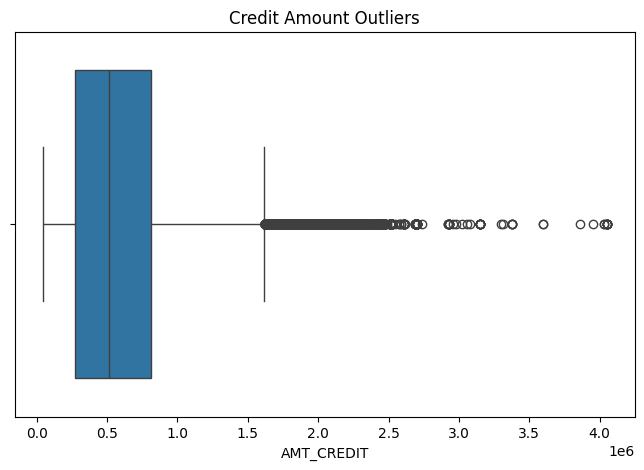

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['AMT_CREDIT'])

plt.title("Credit Amount Outliers")
plt.show()

We cap at:

1st percentile
99th percentile

In [11]:
def cap_outliers(series):

    lower = series.quantile(0.01)
    upper = series.quantile(0.99)

    return np.clip(series, lower, upper)

In [12]:
outlier_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY'
]

for col in outlier_cols:
    df[col] = cap_outliers(df[col])

In [13]:
df['CREDIT_INCOME_RATIO'] = (
    df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
)

/tmp/ipykernel_8427/145970317.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['CREDIT_INCOME_RATIO'] = (


In [14]:
df['ANNUITY_INCOME_RATIO'] = (
    df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
)

/tmp/ipykernel_8427/869412570.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ANNUITY_INCOME_RATIO'] = (


In [15]:
df['EMPLOYMENT_YEARS'] = abs(df['DAYS_EMPLOYED']) / 365

/tmp/ipykernel_8427/602585347.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['EMPLOYMENT_YEARS'] = abs(df['DAYS_EMPLOYED']) / 365


In [16]:
df['CREDIT_TERM'] = (
    df['AMT_CREDIT'] / df['AMT_ANNUITY']
)

/tmp/ipykernel_8427/2357217388.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['CREDIT_TERM'] = (


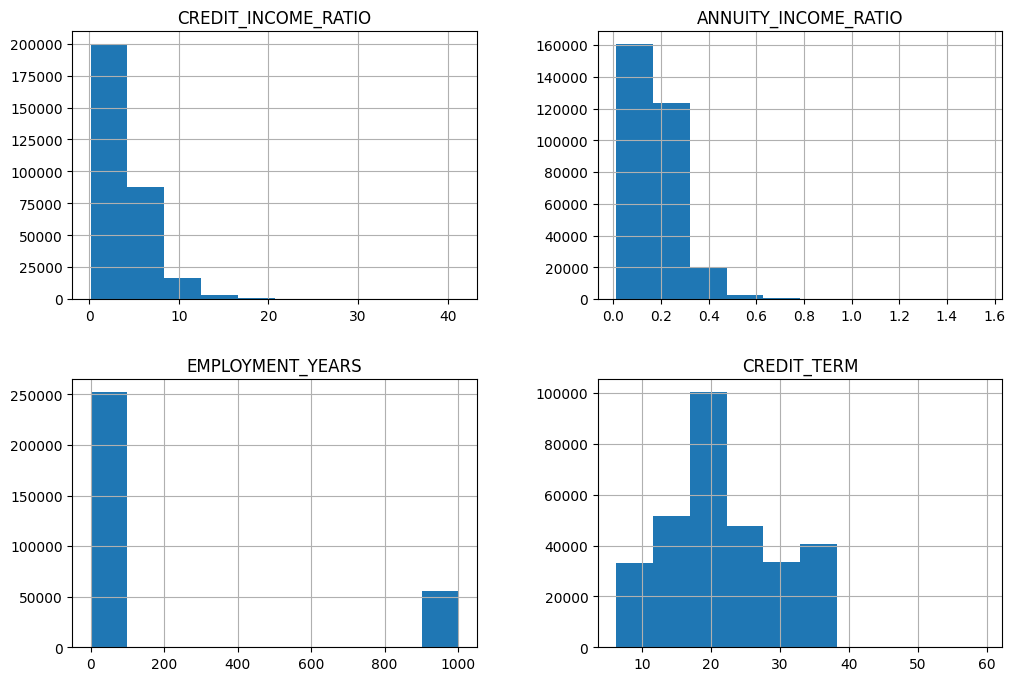

In [17]:
engineered_cols = [
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'EMPLOYMENT_YEARS',
    'CREDIT_TERM'
]

df[engineered_cols].hist(figsize=(12,8))

plt.show()

In [18]:
corr = df[engineered_cols + ['TARGET']].corr()

corr['TARGET'].sort_values(ascending=False)

,TARGET
TARGET,1.000000
ANNUITY_INCOME_RATIO,0.015036
CREDIT_INCOME_RATIO,-0.007833
CREDIT_TERM,-0.032446
EMPLOYMENT_YEARS,-0.047046


In [19]:
df.to_csv('/content/cleaned_application_train.csv', index=False)

In [20]:
from google.colab import files
files.download('/content/cleaned_application_train.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>